In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

In [29]:
df = pd.read_csv('/kaggle/input/datasets/honey/_priyatweets/Tweets (1).csv')

print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [30]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower()

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [31]:
texts = df['clean_text'].tolist()

label_map = {
    'positive': 1,
    'negative': 0,
    'neutral': 2
}

labels = df['sentiment'].map(label_map).tolist()

In [32]:
df = df.sample(200)

In [33]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

Dataset Class

In [34]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

dataset = SimpleDataset(encodings, labels)
loader = DataLoader(dataset, batch_size=2)

Load Model (with Attention Output)

In [35]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,   # changed from 2 → 3
    output_attentions=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning

In [36]:
for i, batch in enumerate(loader):
    if i == 20:   # stop after 20 batches
        break

    optimizer.zero_grad()
    
    outputs = model(**batch)
    loss = outputs.loss
    
    loss.backward()
    optimizer.step()

    print("Loss:", loss.item())

Loss: 1.0553488731384277
Loss: 1.301145076751709
Loss: 1.0947908163070679
Loss: 1.187368392944336
Loss: 1.1377670764923096
Loss: 1.1072964668273926
Loss: 1.2259135246276855
Loss: 1.1369500160217285
Loss: 1.2055754661560059
Loss: 1.0526026487350464
Loss: 1.1328959465026855
Loss: 0.959640383720398
Loss: 1.0055476427078247
Loss: 1.2592742443084717
Loss: 1.2650353908538818
Loss: 1.3644548654556274
Loss: 1.2943241596221924
Loss: 0.8147575855255127
Loss: 1.0041097402572632
Loss: 1.2422912120819092


Extract Attention Weights

In [37]:
model.eval()

inputs = tokenizer("I love this product", return_tensors="pt")
outputs = model(**inputs)

attentions = outputs.attentions  # tuple of layers

Visualize Attention Heatmap

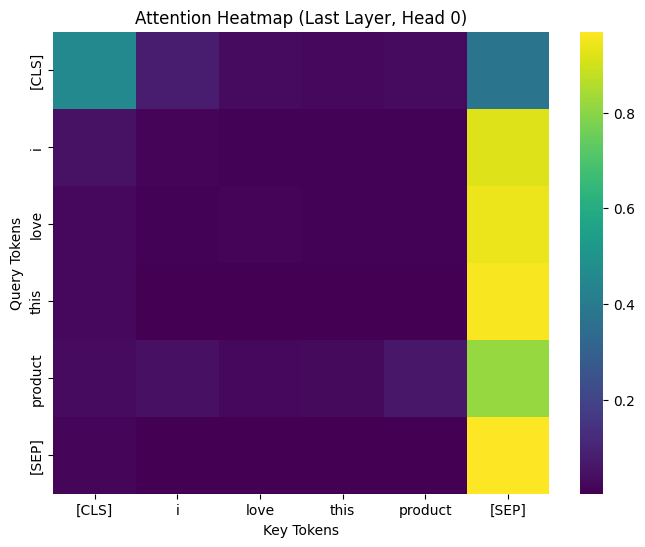

In [38]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

attention = attentions[-1][0][0].detach().numpy()  # last layer, head 0

plt.figure(figsize=(8,6))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Heatmap (Last Layer, Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()